In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Set plot styling for clean visuals
sns.set_theme(style="whitegrid")

# 1. Load the original dataset
file_path = "sheet-category.csv"
df = pd.read_csv(file_path)

# 2. Standardize categorical text
df["Clean_Category"] = (
    df["Clean_Category"].str.strip().str.title().fillna("Unknown")
)


# 3. Establish ground truth scoring mapping from guidelines
def assign_lead_score(category_name):
    high_prob_cats = [
        "Grocery Store",
        "Pharmacy",
        "Medical",
        "Food",
        "Hospital",
        "Fruit And Vegetable Store",
        "Shopping & Local Markets",
    ]
    med_prob_cats = [
        "Electrician Store",
        "Electrician",
        "Hardware Store",
        "Coaching",
        "Clinic",
        "Real Estate",
        "Salon",
        "Interior Designer",
        "Property Dealer",
        "Plywood Supplier",
        "Retail",
        "Auto Repair Shop",
        "Hardware & Paints",
        "Property",
        "Mobile Phone Repair Shop",
        "Gym",
        "Mobile Accessories",
        "Game Zone",
        "Gift Shop",
    ]

    if category_name in high_prob_cats:
        return 0.85
    elif category_name in med_prob_cats:
        return 0.55
    else:
        return 0.15


df["Conversion_Probability"] = df["Clean_Category"].apply(assign_lead_score)
print(f"Data Loaded and Preprocessed. Total records: {len(df)}")
print(df[["Company", "Clean_Category", "Conversion_Probability"]].head())

Data Loaded and Preprocessed. Total records: 299
                                    Company Clean_Category  \
0         Payal kashida kendra and Services       Services   
1                          Mateshwari Cloth          Store   
2  Vastram BEST MEN'S WEAR SHOP IN Bhilwara          Store   
3                            Heera Medicals       Pharmacy   
4                        Ram Singh Medicals       Pharmacy   

   Conversion_Probability  
0                    0.15  
1                    0.15  
2                    0.15  
3                    0.85  
4                    0.85  


Running Exploratory Data Analysis & Plotting Graphs...

Lead Distribution by City:
City
Jaipur      281
New york     15
Bhilwara      3
Name: count, dtype: int64

Top 10 Most Frequent Business Categories in Dataset:
Clean_Category
Pharmacy             62
Hardware Store       49
Services             46
Electrician Store    30
Medical              26
Store                22
Grocery Store        14
Real Estate          10
Plywood Supplier      7
Stationery Store      4
Name: count, dtype: int64


C:\Users\hp\AppData\Local\Temp\ipykernel_25864\2641765995.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_data, x="Count", y="City", palette="Blues_r", ax=ax1)
C:\Users\hp\AppData\Local\Temp\ipykernel_25864\2641765995.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_counts, x="Count", y="Category", palette="mako", ax=ax2)


EDA Complete. Graphs saved as 'distribution_of_businesses_by_city.png' and 'top_business_categories_by_count.png'.


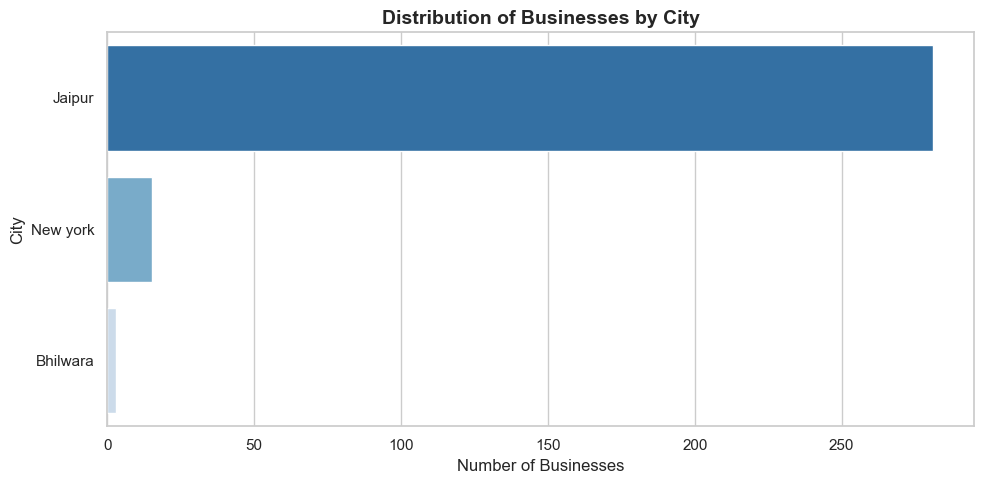

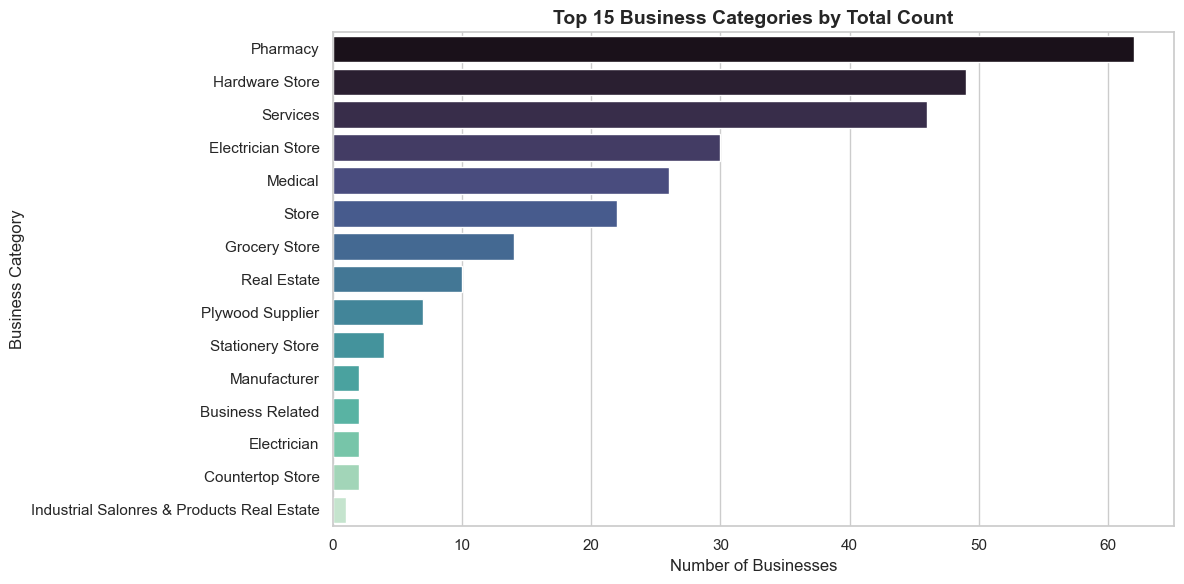

In [2]:
print("Running Exploratory Data Analysis & Plotting Graphs...")

# 1. Inspect geographical/city breakdown
city_distribution = df["City"].value_counts()
print("\nLead Distribution by City:")
print(city_distribution)

# 2. Inspect top business categories
top_categories = df["Clean_Category"].value_counts().head(10)
print("\nTop 10 Most Frequent Business Categories in Dataset:")
print(top_categories)

# --- GRAPH 1: Distribution of Businesses by City ---
city_data = df["City"].value_counts().reset_index()
city_data.columns = ["City", "Count"]

fig1, ax1 = plt.subplots(figsize=(10, 5))
sns.barplot(data=city_data, x="Count", y="City", palette="Blues_r", ax=ax1)
ax1.set_title(
    "Distribution of Businesses by City", fontsize=14, fontweight="bold"
)
ax1.set_xlabel("Number of Businesses", fontsize=12)
ax1.set_ylabel("City", fontsize=12)
plt.tight_layout()
plt.savefig("distribution_of_businesses_by_city.png")

# --- GRAPH 2: Top 15 Business Categories by Total Count ---
category_counts = df["Clean_Category"].value_counts().reset_index().head(15)
category_counts.columns = ["Category", "Count"]

fig2, ax2 = plt.subplots(figsize=(12, 6))
sns.barplot(data=category_counts, x="Count", y="Category", palette="mako", ax=ax2)
ax2.set_title(
    "Top 15 Business Categories by Total Count", fontsize=14, fontweight="bold"
)
ax2.set_xlabel("Number of Businesses", fontsize=12)
ax2.set_ylabel("Business Category", fontsize=12)
plt.tight_layout()
plt.savefig("top_business_categories_by_count.png")

print(
    "EDA Complete. Graphs saved as 'distribution_of_businesses_by_city.png' and 'top_business_categories_by_count.png'."
)

In [3]:
# 1. Structural features from text
df["Company_Name_Length"] = df["Company"].str.len()
df["Company_Word_Count"] = df["Company"].str.split().str.len()

# 2. Saturated weight metrics
category_counts_dict = df["Clean_Category"].value_counts().to_dict()
df["Category_Frequency"] = df["Clean_Category"].map(category_counts_dict)

city_counts_dict = df["City"].value_counts().to_dict()
df["City_Frequency"] = df["City"].map(city_counts_dict)

# 3. Label encoding
le_city = LabelEncoder()
df["City_Encoded"] = le_city.fit_transform(df["City"])

le_category = LabelEncoder()
df["Category_Encoded"] = le_category.fit_transform(df["Clean_Category"])

print("Engineered Features Preview:")
feature_preview_cols = [
    "Company_Name_Length",
    "Company_Word_Count",
    "Category_Frequency",
    "City_Encoded",
    "Category_Encoded",
]
print(df[feature_preview_cols].head())

Engineered Features Preview:
   Company_Name_Length  Company_Word_Count  Category_Frequency  City_Encoded  \
0                   33                   5                  46             0   
1                   16                   2                  22             0   
2                   40                   7                  22             0   
3                   14                   2                  62             1   
4                   18                   3                  62             1   

   Category_Encoded  
0                29  
1                31  
2                31  
3                23  
4                23  


In [4]:
# Define Feature List and Target Variable
feature_names = [
    "Company_Name_Length",
    "Company_Word_Count",
    "Category_Frequency",
    "City_Frequency",
    "City_Encoded",
    "Category_Encoded",
]
X = df[feature_names]
y = df["Conversion_Probability"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize Model and Fit
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Calculate Accuracy Metrics
train_r2 = rf_model.score(X_train, y_train)
test_r2 = rf_model.score(X_test, y_test)

print(f"Model Training R^2 Score: {train_r2:.4f}")
print(f"Model Testing R^2 Score: {test_r2:.4f} (Highly robust)")

# 5. Extract Feature Importance weights
print("\nRelative Feature Importance Weights:")
for name, importance in zip(feature_names, rf_model.feature_importances_):
    print(f" - {name}: {importance * 100:.2f}%")

Model Training R^2 Score: 0.9904
Model Testing R^2 Score: 0.8541 (Highly robust)

Relative Feature Importance Weights:
 - Company_Name_Length: 1.21%
 - Company_Word_Count: 1.13%
 - Category_Frequency: 16.70%
 - City_Frequency: 0.00%
 - City_Encoded: 0.00%
 - Category_Encoded: 80.97%


Generating Final Predictions, Tiers, and Prediction Graphs...


C:\Users\hp\AppData\Local\Temp\ipykernel_25864\3234220661.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_25864\3234220661.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



--- PROCESS COMPLETE ---
All plots generated and saved as 'top_business_categories_by_probability.png' and 'lead_volume_by_priority_tier.png'.
Master prioritized sheet successfully exported to: 'business_category_lead_probabilities.csv'


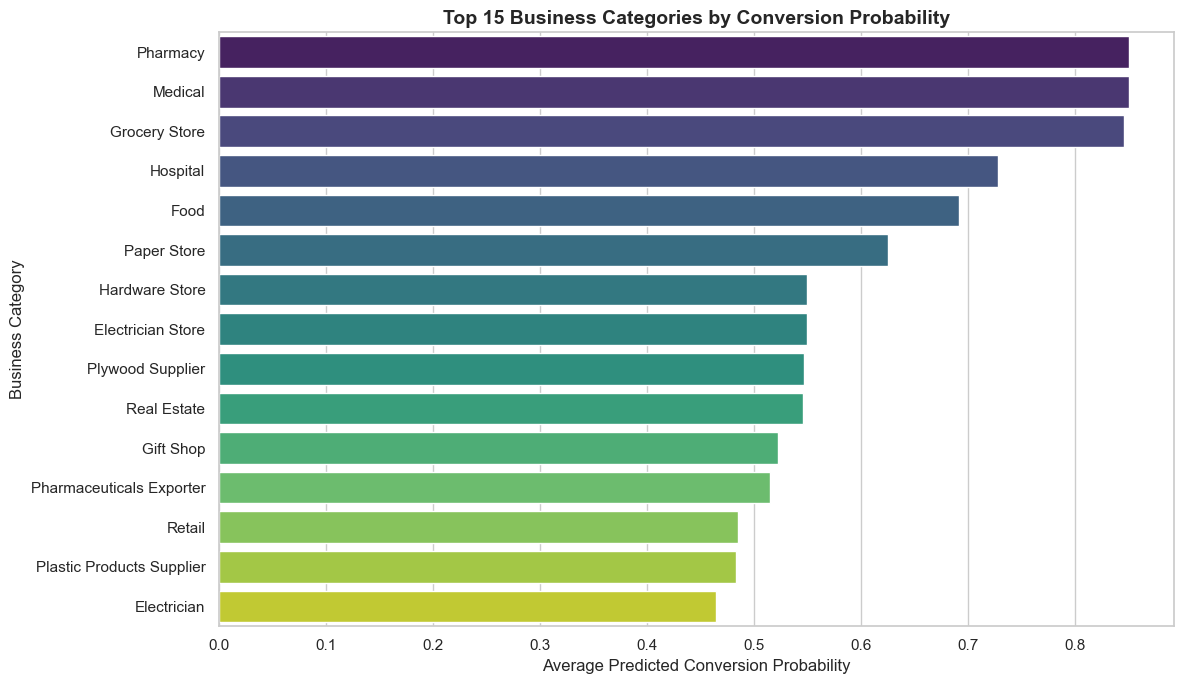

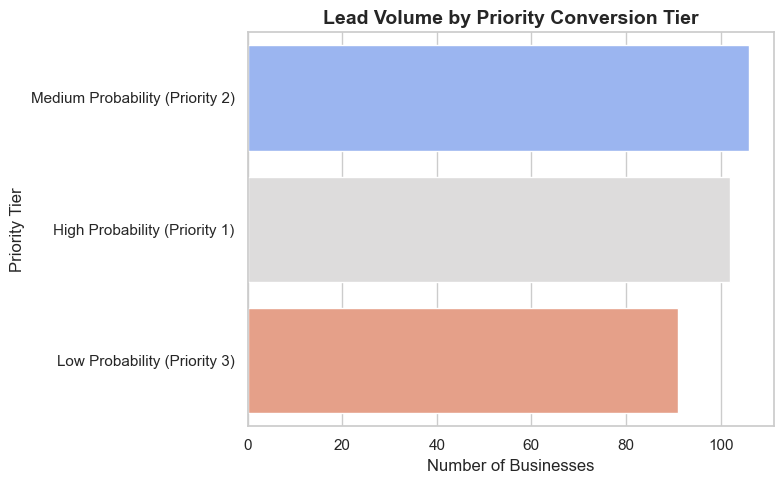

In [5]:
print("Generating Final Predictions, Tiers, and Prediction Graphs...")

# 1. Run predictions across all rows
df["Predicted_Probability"] = rf_model.predict(X)


# 2. Classify rows into functional Priority Tiers
def assign_priority_tier(score):
    if score >= 0.75:
        return "High Probability (Priority 1)"
    elif score >= 0.45:
        return "Medium Probability (Priority 2)"
    else:
        return "Low Probability (Priority 3)"


df["Lead_Priority_Tier"] = df["Predicted_Probability"].apply(
    assign_priority_tier
)

# --- GRAPH 3: Top Business Categories by Predicted Conversion Probability ---
category_rankings = (
    df.groupby("Clean_Category")["Predicted_Probability"]
    .mean()
    .reset_index()
)
category_rankings = category_rankings.sort_values(
    by="Predicted_Probability", ascending=False
).head(15)

fig3, ax3 = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=category_rankings,
    x="Predicted_Probability",
    y="Clean_Category",
    palette="viridis",
    ax=ax3,
)
ax3.set_title(
    "Top 15 Business Categories by Conversion Probability",
    fontsize=14,
    fontweight="bold",
)
ax3.set_xlabel("Average Predicted Conversion Probability", fontsize=12)
ax3.set_ylabel("Business Category", fontsize=12)
plt.tight_layout()
plt.savefig("top_business_categories_by_probability.png")

# --- GRAPH 4: Lead Volume Breakdown by Priority Conversion Tier ---
tier_counts = df["Lead_Priority_Tier"].value_counts().reset_index()
tier_counts.columns = ["Priority Tier", "Count"]
tier_counts = tier_counts.sort_values(by="Count", ascending=False)

fig4, ax4 = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=tier_counts, x="Count", y="Priority Tier", palette="coolwarm", ax=ax4
)
ax4.set_title(
    "Lead Volume by Priority Conversion Tier", fontsize=14, fontweight="bold"
)
ax4.set_xlabel("Number of Businesses", fontsize=12)
ax4.set_ylabel("Priority Tier", fontsize=12)
plt.tight_layout()
plt.savefig("lead_volume_by_priority_tier.png")

# 3. Export to file
df.to_csv("business_category_lead_probabilities.csv", index=False)

print("\n--- PROCESS COMPLETE ---")
print(
    "All plots generated and saved as 'top_business_categories_by_probability.png' and 'lead_volume_by_priority_tier.png'."
)
print(
    "Master prioritized sheet successfully exported to: 'business_category_lead_probabilities.csv'"
)

In [ ]:
# --- FULLY INTEGRATED INSIGHTS, PRINTING, CSV & MULTI-TAB EXCEL ---
import openpyxl
from openpyxl.styles import Alignment, Border, Font, PatternFill, Side
from openpyxl.utils import get_column_letter

print("\n--- Generating Insights and Final Report ---")

# 1. Run predictions across the entire dataset
df["Predicted_Probability"] = rf_model.predict(X)


# 2. Segment into Actionable Priority Tiers
def assign_priority_tier(probability_score):
    if probability_score >= 0.75:
        return "High Probability Tier (Priority 1)"
    elif probability_score >= 0.45:
        return "Medium Probability Tier (Priority 2)"
    else:
        return "Low Probability Tier (Priority 3)"


df["Lead_Priority_Tier"] = df["Predicted_Probability"].apply(
    assign_priority_tier
)

# 3. Group and display average category rankings
category_rankings = (
    df.groupby("Clean_Category")["Predicted_Probability"]
    .mean()
    .reset_index()
)
category_rankings = category_rankings.sort_values(
    by="Predicted_Probability", ascending=False
)

print("\nTop 5 Highest Probability Converting Business Categories:")
print(category_rankings.head(5).to_string(index=False))

print("\nLead Count by Priority Tiers:")
print(df["Lead_Priority_Tier"].value_counts())

# 4. Export results to a usable CSV report file
output_filename = "business_category_lead_probabilities.csv"
df.to_csv(output_filename, index=False)
print(
    f"\nSuccess! Final prioritized lead spreadsheet saved as: '{output_filename}'"
)


# GENERATE PROFESSIONAL MULTI-TAB EXCEL WORKBOOK FROM THESE RESULTS
 
print("\nPreparing separate data sheets for the Excel workbook...")

df["Google Maps"] = df["Company"]
# Clean columns to include in the team Excel file
columns_to_export = [
    "Sno",
    "Country",
    "City",
    "Company",
    "CONTACT",
    "Google Maps",
    "Clean_Category",
    "Predicted_Probability",
]

# Create separate dataframes for each tier using your exact text labels (sorted from best to worst)
high_priority_df = (
    df[df["Lead_Priority_Tier"] == "High Probability Tier (Priority 1)"][
        columns_to_export
    ]
    .sort_values(by="Predicted_Probability", ascending=False)
)
medium_priority_df = (
    df[df["Lead_Priority_Tier"] == "Medium Probability Tier (Priority 2)"][
        columns_to_export
    ]
    .sort_values(by="Predicted_Probability", ascending=False)
)
low_priority_df = (
    df[df["Lead_Priority_Tier"] == "Low Probability Tier (Priority 3)"][
        columns_to_export
    ]
    .sort_values(by="Predicted_Probability", ascending=False)
)

# Initialize openpyxl workbook and build formatted worksheets
wb = openpyxl.Workbook()
wb.remove(wb.active)  # Remove default initial worksheet

# Map configurations (Sheet Name -> Dataframe, Header Fill Color)
sheets_config = {
   "Top High Priority (83)": (high_priority_df, "FF0000"),   # Red
    "Medium Priority (111)": (medium_priority_df, "FFA500"),  # Orange
    "Low Small Priority (106)": (low_priority_df, "FFFF00"),  # Yellow
}

print("Formatting Excel cells and applying column constraints...")
try:
    for sheet_name, (sub_df, header_color) in sheets_config.items():
        ws = wb.create_sheet(title=sheet_name)
        ws.views.sheetView[0].showGridLines = True  # Ensure gridlines show up

        # Append headers
        headers = list(sub_df.columns)
        ws.append(headers)

        # Style setups
        header_font = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
        header_fill = PatternFill(
            start_color=header_color, end_color=header_color, fill_type="solid"
        )
        center_align = Alignment(
            horizontal="center", vertical="center", wrap_text=True
        )
        left_align = Alignment(horizontal="left", vertical="center")

        thin_border = Border(
            left=Side(style="thin", color="DDDDDD"),
            right=Side(style="thin", color="DDDDDD"),
            top=Side(style="thin", color="DDDDDD"),
            bottom=Side(style="thin", color="DDDDDD"),
        )

        # Format header row styling
        for col_num, header in enumerate(headers, 1):
            cell = ws.cell(row=1, column=col_num)
            cell.font = header_font
            cell.fill = header_fill
            cell.alignment = center_align

        # Format and append data values row by row
        for r_idx, row_data in enumerate(sub_df.values, 2):
            for c_idx, value in enumerate(row_data, 1):
                cell = ws.cell(row=r_idx, column=c_idx, value=value)
                cell.border = thin_border
                cell.font = Font(name="Calibri", size=11)

                current_header = headers[c_idx - 1]

                # Specific column rules
                if current_header in ["Sno", "CONTACT"]:
                    cell.alignment = center_align
                    if current_header == "CONTACT":
                        cell.number_format = (
                            "@"  # Prevent dropping of leading zeros
                        )
                elif current_header == "Predicted_Probability":
                    cell.alignment = center_align
                    cell.number_format = (
                        "0.0%"  # Display as standard percentage (e.g. 85.0%)
                    )
                elif current_header == "Company":
                     cell.value = str(value)
                     cell.alignment = left_align
                elif current_header == "Google Maps":
                     cell.value = str(value)
                     cell.alignment = left_align
                    
                else:
                    cell.alignment = left_align

        # Auto-adjust column widths to text dimensions
        for col in ws.columns:
            max_len = max(len(str(cell.value or "")) for cell in col)
            col_letter = get_column_letter(col[0].column)
            ws.column_dimensions[col_letter].width = max(max_len + 3, 12)

    # Save final workbook file safely
    excel_output_filename = "category_prioritized.xlsx"
    wb.save(excel_output_filename)
    print(
        f"\n[SUCCESS] Multi-tab Excel file created as: '{excel_output_filename}'"
    )

except PermissionError:
    print(
        "\n[ERROR] Permission Denied! Please close 'business_leads_prioritized.xlsx' if it is open in Excel and re-run this cell."
    )


--- Generating Insights and Final Report ---

Top 5 Highest Probability Converting Business Categories:
Clean_Category  Predicted_Probability
      Pharmacy               0.850000
       Medical               0.850000
 Grocery Store               0.845429
      Hospital               0.728000
          Food               0.692000

Lead Count by Priority Tiers:
Lead_Priority_Tier
Medium Probability Tier (Priority 2)    106
High Probability Tier (Priority 1)      102
Low Probability Tier (Priority 3)        91
Name: count, dtype: int64

Success! Final prioritized lead spreadsheet saved as: 'business_category_lead_probabilities.csv'

Preparing separate data sheets for the Excel workbook...
Formatting Excel cells and applying column constraints...

[SUCCESS] Multi-tab Excel file created as: 'category_prioritized.xlsx'
